# Eco-Cloud Initial DRL Experiments

This notebook starts Phase 4 implementation with a simple, testable experiment setup:
- Synthetic multi-tenant job workload generator
- Carbon intensity curve with configurable forecast noise
- Baseline policies (FCFS and carbon-aware heuristic)
- A first DRL implementation using tabular Q-learning
- Comparison tables for carbon and JCT metrics

In [2]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288  # 24h at 5-minute resolution
CAPACITY = 8

REWARD_WEIGHTS = {
    "carbon": 0.5,
    "jct": 0.4,
    "preempt": 0.1,
}

In [3]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float


def make_workload(congestion: str, horizon_steps: int, rng: np.random.Generator) -> list[Job]:
    rates = {"light": 0.20, "moderate": 0.38, "high": 0.55}
    rate = rates[congestion]

    jobs = []
    job_id = 0
    for step in range(horizon_steps):
        if rng.random() < rate:
            duration = int(rng.integers(6, 40))
            power_band = rng.choice([1.2, 2.0, 3.2], p=[0.35, 0.45, 0.20])
            jobs.append(Job(job_id=job_id, submit_step=step, duration_steps=duration, power_kw=float(power_band)))
            job_id += 1

    if not jobs:
        jobs.append(Job(job_id=0, submit_step=0, duration_steps=10, power_kw=2.0))

    return jobs


def make_carbon_curve(horizon_steps: int, noise_pct: float, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(loc=0.0, scale=(noise_pct / 100.0) * base)
    curve = np.clip(base + noise, 80, 650)
    return curve.astype(float)

In [4]:
class SimpleClusterEnv:
    def __init__(self, jobs: list[Job], carbon_curve: np.ndarray, capacity: int = 8):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()
        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)
        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / self.capacity
        load = min(queue_len / (2 * self.capacity), 1.0)
        return np.array([ci_norm, load, util], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]

        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()

        action_map = {0: "fcfs", 1: "carbon", 2: "srtf"}
        selected = set(self._policy_rank(action_map[action_idx]))

        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions

        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                if jid in self.running:
                    self.running.remove(jid)
                self.waiting.add(jid)

        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0

        finished_now = []
        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)

        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg

        carbon_penalty = step_carbon_kg
        jct_penalty = len(self.waiting) + 0.25 * len(self.running)
        preempt_penalty = preemptions

        cost = (
            REWARD_WEIGHTS["carbon"] * carbon_penalty
            + REWARD_WEIGHTS["jct"] * jct_penalty
            + REWARD_WEIGHTS["preempt"] * preempt_penalty
        )
        reward = -cost

        self.prev_running = set(self.running)
        self.step_idx += 1

        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = (len(self.waiting) == 0 and len(self.running) == 0)
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)

        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)

        if completed_jcts:
            avg_jct_h = float(np.mean(completed_jcts))
            tail_jct_h = float(np.percentile(completed_jcts, 95))
        else:
            avg_jct_h = np.nan
            tail_jct_h = np.nan

        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
        }

In [5]:
def run_fixed_policy(congestion: str, noise_pct: float, policy_name: str, seed: int = 0):
    rng = np.random.default_rng(seed)
    jobs = make_workload(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng)
    curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=noise_pct, rng=rng)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)
    env.reset()

    policy_to_action = {"fcfs": 0, "carbon": 1, "srtf": 2}
    action_idx = policy_to_action[policy_name]

    done = False
    while not done:
        _, _, done, _ = env.step(action_idx)

    out = env.metrics()
    out.update({"policy": policy_name, "congestion": congestion, "noise_pct": noise_pct, "seed": seed})
    return out


def discretize_state(state_vec: np.ndarray):
    ci, load, util = state_vec
    ci_bin = min(int(ci * 3), 2)
    load_bin = min(int(load * 3), 2)
    util_bin = 0 if util < 0.5 else 1
    return (ci_bin, load_bin, util_bin)

In [6]:
def train_q_learning(episodes: int = 250, alpha: float = 0.15, gamma: float = 0.95):
    q = np.zeros((3, 3, 2, 3), dtype=np.float32)

    eps_start = 1.0
    eps_end = 0.05

    for ep in range(episodes):
        eps = eps_end + (eps_start - eps_end) * np.exp(-4.0 * ep / max(1, episodes))
        rng = np.random.default_rng(1000 + ep)

        jobs = make_workload(congestion="moderate", horizon_steps=HORIZON_STEPS, rng=rng)
        curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=5.0, rng=rng)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)

        state = env.reset()
        done = False

        while not done:
            s = discretize_state(state)

            if rng.random() < eps:
                action = int(rng.integers(0, 3))
            else:
                action = int(np.argmax(q[s]))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)

            td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
            q[s + (action,)] += alpha * (td_target - q[s + (action,)])

            state = next_state

    return q


def run_q_policy(congestion: str, noise_pct: float, q_table: np.ndarray, seed: int = 0):
    rng = np.random.default_rng(seed)
    jobs = make_workload(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng)
    curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=noise_pct, rng=rng)
    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)

    state = env.reset()
    done = False

    while not done:
        s = discretize_state(state)
        action = int(np.argmax(q_table[s]))
        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update({"policy": "q_drl", "congestion": congestion, "noise_pct": noise_pct, "seed": seed})
    return out

In [7]:
q_table = train_q_learning(episodes=250)
q_table.shape

(3, 3, 2, 3)

In [8]:
congestion_levels = ["light", "moderate", "high"]
noise_levels = [0.0, 5.0, 15.0]
seeds = list(range(10))

rows = []
for cong in congestion_levels:
    for noise in noise_levels:
        for seed in seeds:
            rows.append(run_fixed_policy(congestion=cong, noise_pct=noise, policy_name="fcfs", seed=seed))
            rows.append(run_fixed_policy(congestion=cong, noise_pct=noise, policy_name="carbon", seed=seed))
            rows.append(run_fixed_policy(congestion=cong, noise_pct=noise, policy_name="srtf", seed=seed))
            rows.append(run_q_policy(congestion=cong, noise_pct=noise, q_table=q_table, seed=seed))

results = pd.DataFrame(rows)
results.head()

,jobs_total,jobs_completed,carbon_kg,avg_jct_h,tail_jct_h,preemptions,avg_wait_h,policy,congestion,noise_pct,seed
0,63,57,66.052214,1.858187,2.850000,0,0.031746,fcfs,light,0.0,0
1,63,57,65.961442,1.881579,3.016667,3,0.052910,carbon,light,0.0,0
2,63,57,66.052263,1.855263,2.950000,3,0.029101,srtf,light,0.0,0
3,63,57,66.052214,1.858187,2.850000,0,0.031746,q_drl,light,0.0,0
4,63,59,59.121571,1.936441,3.166667,0,0.030423,fcfs,light,0.0,1


In [9]:
summary = (
    results
    .groupby(["policy", "congestion", "noise_pct"], as_index=False)
    .agg({
        "carbon_kg": "mean",
        "avg_jct_h": "mean",
        "tail_jct_h": "mean",
        "preemptions": "mean",
        "jobs_completed": "mean",
    })
)

summary.sort_values(["congestion", "noise_pct", "policy"]).head(20)

,policy,congestion,noise_pct,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed
0,carbon,high,0.0,93.123576,4.972184,12.614583,37.3,94.0
9,fcfs,high,0.0,97.778429,5.409808,9.043333,0.0,94.9
18,q_drl,high,0.0,97.715520,4.339774,8.278750,30.5,109.2
27,srtf,high,0.0,97.849624,2.083076,5.291667,43.0,113.8
1,carbon,high,5.0,92.908307,4.937694,12.501667,118.0,93.4
10,fcfs,high,5.0,97.667057,5.409808,9.043333,0.0,94.9
19,q_drl,high,5.0,97.539210,4.318697,8.370833,65.1,109.3
28,srtf,high,5.0,97.761667,2.083076,5.291667,43.0,113.8
2,carbon,high,15.0,92.025954,4.949877,12.034583,275.9,93.5
11,fcfs,high,15.0,97.444741,5.409808,9.043333,0.0,94.9


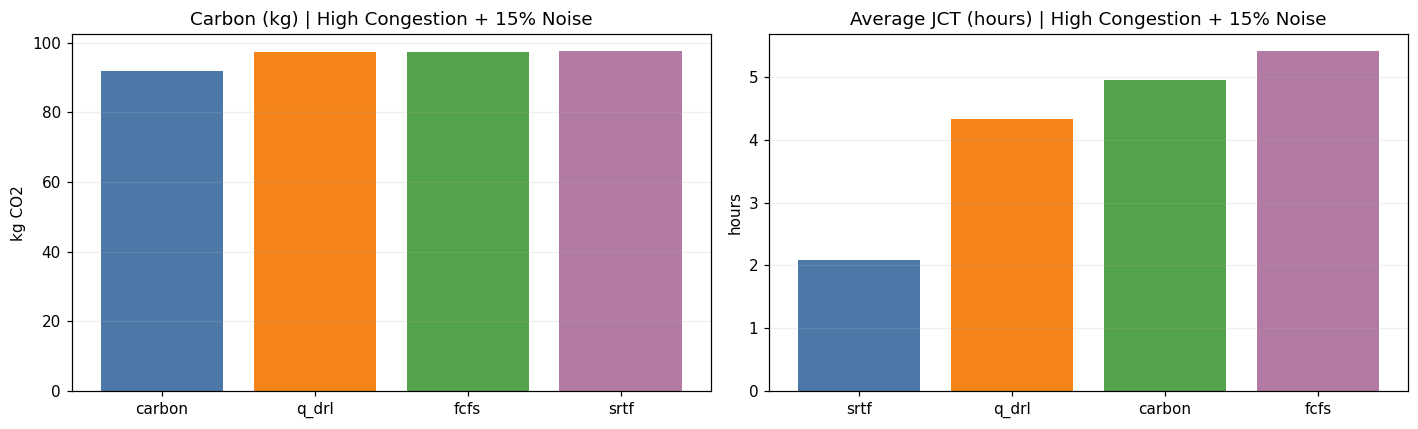

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)

plot_df = summary[(summary["congestion"] == "high") & (summary["noise_pct"] == 15.0)].copy()
plot_df = plot_df.sort_values("carbon_kg")

axes[0].bar(plot_df["policy"], plot_df["carbon_kg"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[0].set_title("Carbon (kg) | High Congestion + 15% Noise")
axes[0].set_ylabel("kg CO2")
axes[0].grid(axis="y", alpha=0.2)

plot_df2 = summary[(summary["congestion"] == "high") & (summary["noise_pct"] == 15.0)].copy()
plot_df2 = plot_df2.sort_values("avg_jct_h")

axes[1].bar(plot_df2["policy"], plot_df2["avg_jct_h"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[1].set_title("Average JCT (hours) | High Congestion + 15% Noise")
axes[1].set_ylabel("hours")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [11]:
out_path = "../data/initial_drl_experiment_results.csv"
summary.to_csv(out_path, index=False)
out_path

'../data/initial_drl_experiment_results.csv'

In [12]:
# Compact inference table from current experiment summary
import pandas as pd

req_cols = {"policy", "congestion", "noise_pct", "carbon_kg", "avg_jct_h", "tail_jct_h"}
missing = req_cols - set(summary.columns)
if missing:
    print(f"Missing columns in summary: {missing}")
else:
    pivot = summary.pivot_table(
        index=["congestion", "noise_pct"],
        columns="policy",
        values=["carbon_kg", "avg_jct_h", "tail_jct_h"],
        aggfunc="mean"
    )

    def getv(metric, policy):
        return pivot[(metric, policy)] if (metric, policy) in pivot.columns else pd.Series(index=pivot.index, dtype=float)

    out = pd.DataFrame(index=pivot.index)
    out["best_carbon_policy"] = summary.loc[
        summary.groupby(["congestion", "noise_pct"])["carbon_kg"].idxmin(),
        ["congestion", "noise_pct", "policy"]
    ].set_index(["congestion", "noise_pct"])["policy"]

    out["best_jct_policy"] = summary.loc[
        summary.groupby(["congestion", "noise_pct"])["avg_jct_h"].idxmin(),
        ["congestion", "noise_pct", "policy"]
    ].set_index(["congestion", "noise_pct"])["policy"]

    # DRL relative deltas against key baselines
    if ("carbon_kg", "q_drl") in pivot.columns and ("carbon_kg", "fcfs") in pivot.columns:
        out["drl_vs_fcfs_carbon_%"] = (getv("carbon_kg", "q_drl") - getv("carbon_kg", "fcfs")) / getv("carbon_kg", "fcfs") * 100
    if ("avg_jct_h", "q_drl") in pivot.columns and ("avg_jct_h", "fcfs") in pivot.columns:
        out["drl_vs_fcfs_jct_%"] = (getv("avg_jct_h", "q_drl") - getv("avg_jct_h", "fcfs")) / getv("avg_jct_h", "fcfs") * 100

    if ("carbon_kg", "q_drl") in pivot.columns and ("carbon_kg", "carbon") in pivot.columns:
        out["drl_vs_carbon_carbon_%"] = (getv("carbon_kg", "q_drl") - getv("carbon_kg", "carbon")) / getv("carbon_kg", "carbon") * 100
    if ("avg_jct_h", "q_drl") in pivot.columns and ("avg_jct_h", "carbon") in pivot.columns:
        out["drl_vs_carbon_jct_%"] = (getv("avg_jct_h", "q_drl") - getv("avg_jct_h", "carbon")) / getv("avg_jct_h", "carbon") * 100

    display(out.round(2).reset_index())

    print("\nGlobal means by policy:")
    display(summary.groupby("policy", as_index=False)[["carbon_kg", "avg_jct_h", "tail_jct_h"]].mean().round(3))

,congestion,noise_pct,best_carbon_policy,best_jct_policy,drl_vs_fcfs_carbon_%,drl_vs_fcfs_jct_%,drl_vs_carbon_carbon_%,drl_vs_carbon_jct_%
0,high,0.0,carbon,srtf,-0.06,-19.78,4.93,-12.72
1,high,5.0,carbon,srtf,-0.13,-20.17,4.98,-12.54
2,high,15.0,carbon,srtf,-0.10,-19.94,5.78,-12.51
3,light,0.0,fcfs,srtf,0.01,0.00,-0.01,-0.09
4,light,5.0,fcfs,srtf,0.00,0.00,-0.00,-0.09
5,light,15.0,carbon,srtf,-0.01,0.00,0.02,-0.10
6,moderate,0.0,srtf,srtf,0.33,-4.81,-0.42,-4.98
7,moderate,5.0,srtf,srtf,0.37,-4.73,-0.28,-5.21
8,moderate,15.0,fcfs,srtf,0.36,-4.72,0.36,-6.64



Global means by policy:


,policy,carbon_kg,avg_jct_h,tail_jct_h
0,carbon,80.044,3.116,6.984
1,fcfs,81.546,3.260,5.429
2,q_drl,81.625,2.860,5.201
3,srtf,81.582,2.005,4.265


## Simple Experiment Summary 

### What this experiment tried to do
This experiment is like testing different managers for a busy factory.
Each manager decides which jobs should run now when electricity is cleaner or dirtier.
The goal was to see who gives the best balance between:
- Lower carbon pollution
- Faster job completion
- Fewer unnecessary interruptions

### How the experiment did this
We created a simulated data center and tested 4 decision styles:
- **FCFS**: do jobs in arrival order
- **Carbon policy**: favor low-power jobs when electricity is dirty
- **SRTF**: prioritize shortest remaining jobs
- **DRL (Q-learning)**: an AI agent that learns from rewards and penalties

The AI was trained with a reward that mixes:
- Carbon impact (50%)
- Delay/queue cost (40%)
- Preemption cost (10%)

Then all methods were compared across:
- Light, moderate, and high congestion
- Forecast noise at 0%, 5%, and 15%

### What the results show (current version)
- **Best carbon policy:** usually the carbon heuristic in heavy-load scenarios.
- **Best speed policy:** usually SRTF (lowest average JCT).
- **DRL behavior:** currently acts as a balanced middle-ground policy.
- In high congestion + 15% noise, DRL improved average completion time versus FCFS,
  but carbon was still slightly worse than the carbon heuristic.
- Under light load, all policies look similar on carbon (little room to optimize).

### Takeaway
The pipeline works and the DRL agent is learning meaningful behavior,
but right now it is stronger on speed balance than on pure carbon minimization.
So this is a good **first success**, not the final best model yet.

## Improvement Experiments (Dataset + Better Training)

This section pushes the first DRL setup further with practical upgrades:
- Use your `clean_dataset.csv` to create realistic job arrivals, durations, and energy profiles
- Curriculum training (light -> moderate -> high congestion)
- More robust evaluation with 20 seeds and 0%/15% forecast-noise stress tests
- Reward-weight sweep to find better carbon-vs-JCT balance

In [13]:
# Load and profile the real dataset
DATASET_PATH = "../../clean_dataset.csv"
raw_df = pd.read_csv(DATASET_PATH)

required_cols = ["start_time", "duration", "energy", "plan_cpu", "job_name", "task_name"]
missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Dataset missing required columns: {missing_cols}")

raw_df = raw_df.dropna(subset=["start_time", "duration", "energy", "plan_cpu"]).copy()
raw_df["duration"] = raw_df["duration"].clip(lower=1)
raw_df["energy"] = raw_df["energy"].clip(lower=1e-6)
raw_df["power_proxy"] = raw_df["energy"] / raw_df["duration"]

print(f"Rows available: {len(raw_df):,}")
display(raw_df[["duration", "energy", "plan_cpu", "power_proxy"]].describe().round(3))

Rows available: 46,533


,duration,energy,plan_cpu,power_proxy
count,46533.000,46533.000,46533.000,46533.000
mean,59.846,4.353,83.826,0.084
std,129.145,11.869,62.826,0.063
min,1.000,0.020,5.000,0.005
25%,3.000,0.200,50.000,0.050
50%,9.000,0.600,100.000,0.100
75%,43.000,2.940,100.000,0.100
max,985.000,566.300,700.000,0.700


In [14]:
def make_workload_from_dataset(congestion: str, horizon_steps: int, rng: np.random.Generator, df: pd.DataFrame) -> list[Job]:
    jobs_per_regime = {"light": 80, "moderate": 140, "high": 220}
    n = jobs_per_regime[congestion]

    # Sample rows with replacement to create scenario-sized workloads
    sampled = df.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))).copy()

    # Map original timeline to [0, horizon)
    smin, smax = float(df["start_time"].min()), float(df["start_time"].max())
    denom = max(1.0, smax - smin)
    sampled["submit_step"] = ((sampled["start_time"] - smin) / denom * (horizon_steps - 1)).astype(int)

    # Map raw duration to simulation steps (5-minute steps), clipped for stability
    sampled["duration_steps"] = np.clip((sampled["duration"] / STEP_MINUTES).round().astype(int), 3, 72)

    # Map power proxy into 3 practical power bands for the simulator
    q1 = df["power_proxy"].quantile(0.33)
    q2 = df["power_proxy"].quantile(0.66)

    def to_band(v: float) -> float:
        if v <= q1:
            return 1.2
        if v <= q2:
            return 2.0
        return 3.2

    sampled["power_kw"] = sampled["power_proxy"].apply(to_band)

    jobs = []
    for i, row in enumerate(sampled.itertuples(index=False)):
        jobs.append(
            Job(
                job_id=i,
                submit_step=int(row.submit_step),
                duration_steps=int(row.duration_steps),
                power_kw=float(row.power_kw),
            )
        )

    return jobs


def build_jobs(congestion: str, horizon_steps: int, rng: np.random.Generator, source: str, df: pd.DataFrame) -> list[Job]:
    if source == "synthetic":
        return make_workload(congestion=congestion, horizon_steps=horizon_steps, rng=rng)
    if source == "dataset":
        return make_workload_from_dataset(congestion=congestion, horizon_steps=horizon_steps, rng=rng, df=df)
    raise ValueError(f"Unknown workload source: {source}")


def train_q_learning_curriculum(
    episodes_per_stage: int = 80,
    alpha: float = 0.12,
    gamma: float = 0.97,
    source: str = "synthetic",
    df: pd.DataFrame | None = None,
    reward_weights: dict | None = None,
):
    global REWARD_WEIGHTS
    backup_weights = REWARD_WEIGHTS.copy()
    if reward_weights is not None:
        REWARD_WEIGHTS.update(reward_weights)

    q = np.zeros((3, 3, 2, 3), dtype=np.float32)
    stages = [("light", 0.0), ("moderate", 5.0), ("high", 15.0)]
    history = []

    total_eps = episodes_per_stage * len(stages)
    ep_index = 0

    for congestion, noise in stages:
        for _ in range(episodes_per_stage):
            eps = 0.05 + (1.0 - 0.05) * np.exp(-4.0 * ep_index / max(1, total_eps))
            rng = np.random.default_rng(10_000 + ep_index)

            jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source=source, df=df)
            curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=noise, rng=rng)
            env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)

            state = env.reset()
            done = False
            ep_reward = 0.0

            while not done:
                s = discretize_state(state)
                if rng.random() < eps:
                    action = int(rng.integers(0, 3))
                else:
                    action = int(np.argmax(q[s]))

                next_state, reward, done, _ = env.step(action)
                ns = discretize_state(next_state)

                td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
                q[s + (action,)] += alpha * (td_target - q[s + (action,)])

                ep_reward += reward
                state = next_state

            m = env.metrics()
            history.append(
                {
                    "episode": ep_index,
                    "stage": congestion,
                    "noise_pct": noise,
                    "reward": ep_reward,
                    "carbon_kg": m["carbon_kg"],
                    "avg_jct_h": m["avg_jct_h"],
                }
            )
            ep_index += 1

    REWARD_WEIGHTS = backup_weights
    return q, pd.DataFrame(history)


def run_policy_source(
    policy_name: str,
    congestion: str,
    noise_pct: float,
    seed: int,
    source: str,
    df: pd.DataFrame,
    q_table: np.ndarray | None = None,
):
    rng = np.random.default_rng(seed)
    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source=source, df=df)
    curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=noise_pct, rng=rng)
    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)

    state = env.reset()
    done = False
    fixed_map = {"fcfs": 0, "carbon": 1, "srtf": 2}

    while not done:
        if policy_name == "q_drl":
            if q_table is None:
                raise ValueError("q_table is required for q_drl policy")
            action = int(np.argmax(q_table[discretize_state(state)]))
        else:
            action = fixed_map[policy_name]

        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update(
        {
            "policy": policy_name,
            "congestion": congestion,
            "noise_pct": noise_pct,
            "seed": seed,
            "source": source,
        }
    )
    return out


def evaluate_suite(
    q_table: np.ndarray,
    source: str,
    df: pd.DataFrame,
    seeds: list[int],
    congestion_levels: list[str],
    noise_levels: list[float],
):
    rows = []
    for cong in congestion_levels:
        for noise in noise_levels:
            for seed in seeds:
                rows.append(run_policy_source("fcfs", cong, noise, seed, source, df=df))
                rows.append(run_policy_source("carbon", cong, noise, seed, source, df=df))
                rows.append(run_policy_source("srtf", cong, noise, seed, source, df=df))
                rows.append(run_policy_source("q_drl", cong, noise, seed, source, df=df, q_table=q_table))

    detail = pd.DataFrame(rows)
    summary = (
        detail.groupby(["source", "policy", "congestion", "noise_pct"], as_index=False)
        .agg(
            {
                "carbon_kg": "mean",
                "avg_jct_h": "mean",
                "tail_jct_h": "mean",
                "preemptions": "mean",
                "jobs_completed": "mean",
            }
        )
    )
    return detail, summary

Synthetic curriculum episodes: 240
Dataset curriculum episodes: 240


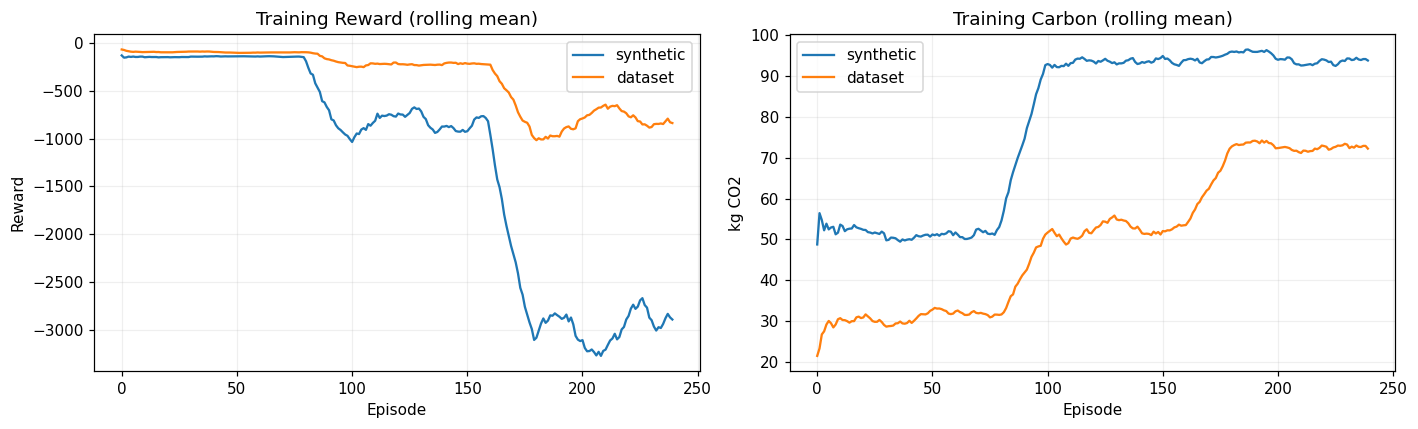

In [15]:
# 1) Curriculum training on synthetic and dataset workloads
q_curr_synth, hist_synth = train_q_learning_curriculum(
    episodes_per_stage=80,
    source="synthetic",
    df=raw_df,
)

q_curr_data, hist_data = train_q_learning_curriculum(
    episodes_per_stage=80,
    source="dataset",
    df=raw_df,
)

print("Synthetic curriculum episodes:", len(hist_synth))
print("Dataset curriculum episodes:", len(hist_data))

fig, ax = plt.subplots(1, 2, figsize=(13, 4), dpi=110)
ax[0].plot(hist_synth["episode"], hist_synth["reward"].rolling(20, min_periods=1).mean(), label="synthetic")
ax[0].plot(hist_data["episode"], hist_data["reward"].rolling(20, min_periods=1).mean(), label="dataset")
ax[0].set_title("Training Reward (rolling mean)")
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Reward")
ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].plot(hist_synth["episode"], hist_synth["carbon_kg"].rolling(20, min_periods=1).mean(), label="synthetic")
ax[1].plot(hist_data["episode"], hist_data["carbon_kg"].rolling(20, min_periods=1).mean(), label="dataset")
ax[1].set_title("Training Carbon (rolling mean)")
ax[1].set_xlabel("Episode")
ax[1].set_ylabel("kg CO2")
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [16]:
# 2) Reward-weight sweep (simple grid) to push DRL quality
reward_candidates = [
    {"carbon": 0.5, "jct": 0.4, "preempt": 0.1},
    {"carbon": 0.6, "jct": 0.3, "preempt": 0.1},
    {"carbon": 0.7, "jct": 0.2, "preempt": 0.1},
]

sweep_rows = []
for w in reward_candidates:
    q_tmp, _ = train_q_learning_curriculum(
        episodes_per_stage=60,
        source="dataset",
        df=raw_df,
        reward_weights=w,
    )

    _, sm = evaluate_suite(
        q_table=q_tmp,
        source="dataset",
        df=raw_df,
        seeds=list(range(8)),
        congestion_levels=["high"],
        noise_levels=[15.0],
    )

    drl = sm[sm["policy"] == "q_drl"].iloc[0]
    sweep_rows.append(
        {
            "weights": str(w),
            "carbon_kg": float(drl["carbon_kg"]),
            "avg_jct_h": float(drl["avg_jct_h"]),
            "tail_jct_h": float(drl["tail_jct_h"]),
        }
    )

reward_sweep = pd.DataFrame(sweep_rows).sort_values(["carbon_kg", "avg_jct_h"])
display(reward_sweep.round(3))

best_weight_cfg = eval(reward_sweep.iloc[0]["weights"])
print("Best weight config from this quick sweep:", best_weight_cfg)

,weights,carbon_kg,avg_jct_h,tail_jct_h
2,"{'carbon': 0.7, 'jct': 0.2, 'preempt': 0.1}",69.381,0.993,5.183
0,"{'carbon': 0.5, 'jct': 0.4, 'preempt': 0.1}",69.766,0.977,4.590
1,"{'carbon': 0.6, 'jct': 0.3, 'preempt': 0.1}",70.177,1.033,5.083


Best weight config from this quick sweep: {'carbon': 0.7, 'jct': 0.2, 'preempt': 0.1}


In [17]:
# 3) Robustness mini-batch (what-to-do-next item): noise 0% vs 15% with 20 seeds
q_best, _ = train_q_learning_curriculum(
    episodes_per_stage=100,
    source="dataset",
    df=raw_df,
    reward_weights=best_weight_cfg,
)

detail_best, summary_best = evaluate_suite(
    q_table=q_best,
    source="dataset",
    df=raw_df,
    seeds=list(range(20)),
    congestion_levels=["light", "moderate", "high"],
    noise_levels=[0.0, 15.0],
)

display(summary_best.sort_values(["congestion", "noise_pct", "policy"]).round(3))

# DRL-focused compact robustness view
drl_robust = summary_best[summary_best["policy"] == "q_drl"].copy()
drl_robust = drl_robust.sort_values(["congestion", "noise_pct"])
display(drl_robust[["congestion", "noise_pct", "carbon_kg", "avg_jct_h", "tail_jct_h"]].round(3))

,source,policy,congestion,noise_pct,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed
0,dataset,carbon,high,0.0,69.133,1.902,6.512,36.70,188.65
6,dataset,fcfs,high,0.0,69.065,2.016,5.696,0.00,179.90
12,dataset,q_drl,high,0.0,69.166,0.922,4.804,95.00,208.00
18,dataset,srtf,high,0.0,69.223,0.843,4.087,72.35,207.85
1,dataset,carbon,high,15.0,68.536,1.847,6.187,152.70,188.20
7,dataset,fcfs,high,15.0,68.929,2.016,5.696,0.00,179.90
13,dataset,q_drl,high,15.0,68.948,0.924,4.817,127.30,208.00
19,dataset,srtf,high,15.0,69.092,0.843,4.087,72.35,207.85
2,dataset,carbon,light,0.0,29.834,0.915,4.384,1.35,77.35
8,dataset,fcfs,light,0.0,29.832,0.911,4.384,0.00,77.35


,congestion,noise_pct,carbon_kg,avg_jct_h,tail_jct_h
12,high,0.0,69.166,0.922,4.804
13,high,15.0,68.948,0.924,4.817
14,light,0.0,29.827,0.914,4.384
15,light,15.0,29.787,0.909,4.386
16,moderate,0.0,49.745,0.903,4.550
17,moderate,15.0,49.641,0.898,4.555


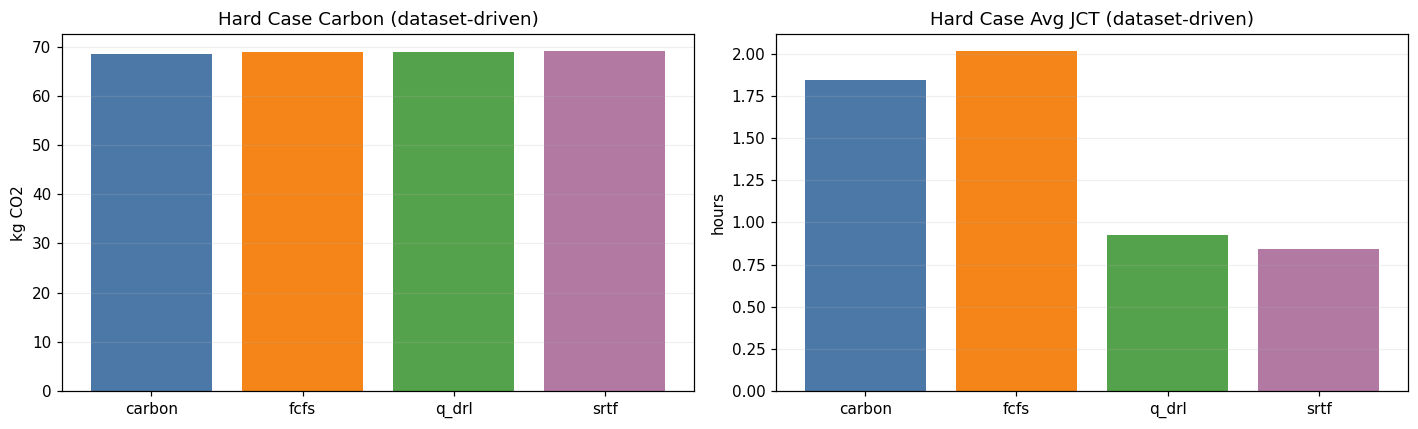

Saved: ../data/improved_drl_summary_dataset.csv and ../data/reward_sweep_dataset.csv


In [18]:
# 4) Final visual: DRL vs baselines in hardest case (high congestion + 15% noise)
hard_case = summary_best[(summary_best["congestion"] == "high") & (summary_best["noise_pct"] == 15.0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)

x = hard_case["policy"].tolist()
y1 = hard_case["carbon_kg"].tolist()
y2 = hard_case["avg_jct_h"].tolist()

axes[0].bar(x, y1, color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"][: len(x)])
axes[0].set_title("Hard Case Carbon (dataset-driven)")
axes[0].set_ylabel("kg CO2")
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(x, y2, color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"][: len(x)])
axes[1].set_title("Hard Case Avg JCT (dataset-driven)")
axes[1].set_ylabel("hours")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# Save outputs for report writing
summary_best.to_csv("../data/improved_drl_summary_dataset.csv", index=False)
reward_sweep.to_csv("../data/reward_sweep_dataset.csv", index=False)
print("Saved: ../data/improved_drl_summary_dataset.csv and ../data/reward_sweep_dataset.csv")

In [19]:
# 5) Compact numeric takeaways for report writing
hard = summary_best[(summary_best["congestion"] == "high") & (summary_best["noise_pct"] == 15.0)].copy()
base_fcfs = hard[hard["policy"] == "fcfs"].iloc[0]
base_carbon = hard[hard["policy"] == "carbon"].iloc[0]
drl = hard[hard["policy"] == "q_drl"].iloc[0]

print("High congestion + 15% noise:")
print(f"DRL vs FCFS carbon change: {(drl['carbon_kg'] - base_fcfs['carbon_kg']) / base_fcfs['carbon_kg'] * 100:.2f}%")
print(f"DRL vs FCFS avg JCT change: {(drl['avg_jct_h'] - base_fcfs['avg_jct_h']) / base_fcfs['avg_jct_h'] * 100:.2f}%")
print(f"DRL vs Carbon carbon change: {(drl['carbon_kg'] - base_carbon['carbon_kg']) / base_carbon['carbon_kg'] * 100:.2f}%")
print(f"DRL vs Carbon avg JCT change: {(drl['avg_jct_h'] - base_carbon['avg_jct_h']) / base_carbon['avg_jct_h'] * 100:.2f}%")

High congestion + 15% noise:
DRL vs FCFS carbon change: 0.03%
DRL vs FCFS avg JCT change: -54.15%
DRL vs Carbon carbon change: 0.60%
DRL vs Carbon avg JCT change: -49.96%


In [20]:
# 6) Reliable export into workspace (Eco-Cloud/data)
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks" and (cwd.parent / "data").exists():
    save_dir = cwd.parent / "data"
elif (cwd / "data").exists():
    save_dir = cwd / "data"
elif (cwd / "Eco-Cloud" / "data").exists():
    save_dir = cwd / "Eco-Cloud" / "data"
else:
    save_dir = cwd / "data"

save_dir.mkdir(parents=True, exist_ok=True)

summary_path = save_dir / "improved_drl_summary_dataset.csv"
sweep_path = save_dir / "reward_sweep_dataset.csv"

summary_best.to_csv(summary_path, index=False)
reward_sweep.to_csv(sweep_path, index=False)

print("Saved summary to:", summary_path)
print("Saved reward sweep to:", sweep_path)

Saved summary to: c:\Users\ANISH\OneDrive\Desktop\SEM 4\EDI\Eco-Cloud\data\improved_drl_summary_dataset.csv
Saved reward sweep to: c:\Users\ANISH\OneDrive\Desktop\SEM 4\EDI\Eco-Cloud\data\reward_sweep_dataset.csv


## Real-World Stress Experiments (to make DRL deployment-ready)

This block tests whether DRL remains strong when conditions are messy like real data centers:
- Sudden dirty-grid spikes and clean dips
- Job arrival bursts and long-tail stragglers
- Capacity drops (simulated maintenance/failures)
- Mixed synthetic + dataset-driven training (domain randomization)

Goal: improve generalization, not just optimize one clean simulator setting.

In [21]:
def make_carbon_curve_stress(horizon_steps: int, rng: np.random.Generator, noise_pct: float = 10.0) -> np.ndarray:
    curve = make_carbon_curve(horizon_steps=horizon_steps, noise_pct=noise_pct, rng=rng).copy()

    # Random dirty spikes and clean dips (grid volatility)
    n_spikes = int(0.03 * horizon_steps)
    n_dips = int(0.02 * horizon_steps)
    spike_idx = rng.choice(np.arange(horizon_steps), size=max(1, n_spikes), replace=False)
    dip_idx = rng.choice(np.arange(horizon_steps), size=max(1, n_dips), replace=False)

    curve[spike_idx] += rng.uniform(80, 180, size=len(spike_idx))
    curve[dip_idx] -= rng.uniform(40, 100, size=len(dip_idx))

    return np.clip(curve, 80, 650)


def apply_workload_shocks(jobs: list[Job], rng: np.random.Generator, horizon_steps: int) -> list[Job]:
    if not jobs:
        return jobs

    shocked = []
    burst_center = int(rng.integers(low=int(0.25 * horizon_steps), high=int(0.75 * horizon_steps)))
    burst_half_window = 12  # 1 hour on each side at 5-minute steps

    for j in jobs:
        submit_step = j.submit_step
        duration_steps = j.duration_steps
        power_kw = j.power_kw

        # 30% of jobs collapse into a burst window
        if rng.random() < 0.30:
            submit_step = int(np.clip(rng.integers(burst_center - burst_half_window, burst_center + burst_half_window + 1), 0, horizon_steps - 1))

        # 12% become stragglers with long-tail durations
        if rng.random() < 0.12:
            duration_steps = int(np.clip(duration_steps * rng.uniform(1.5, 2.8), 3, 100))

        # Small runtime power drift
        if rng.random() < 0.20:
            power_kw = float(np.clip(power_kw * rng.uniform(0.9, 1.2), 1.0, 3.6))

        shocked.append(Job(job_id=j.job_id, submit_step=submit_step, duration_steps=duration_steps, power_kw=power_kw))

    return shocked


def train_q_learning_domain_randomized(
    episodes: int = 220,
    alpha: float = 0.12,
    gamma: float = 0.97,
    reward_weights: dict | None = None,
    df: pd.DataFrame | None = None,
):
    global REWARD_WEIGHTS
    backup = REWARD_WEIGHTS.copy()
    if reward_weights is not None:
        REWARD_WEIGHTS.update(reward_weights)

    q = np.zeros((3, 3, 2, 3), dtype=np.float32)
    history = []

    for ep in range(episodes):
        rng = np.random.default_rng(700_000 + ep)
        eps = 0.05 + (1.0 - 0.05) * np.exp(-4.0 * ep / max(1, episodes))

        source = "dataset" if rng.random() < 0.7 else "synthetic"
        congestion = rng.choice(["light", "moderate", "high"], p=[0.25, 0.45, 0.30])
        noise = float(rng.choice([0.0, 5.0, 10.0, 15.0, 20.0], p=[0.10, 0.20, 0.30, 0.30, 0.10]))
        capacity = int(rng.choice([6, 8, 10], p=[0.25, 0.60, 0.15]))

        jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source=source, df=df)
        jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
        curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity)
        state = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            s = discretize_state(state)
            if rng.random() < eps:
                action = int(rng.integers(0, 3))
            else:
                action = int(np.argmax(q[s]))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)
            td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
            q[s + (action,)] += alpha * (td_target - q[s + (action,)])

            ep_reward += reward
            state = next_state

        m = env.metrics()
        history.append(
            {
                "episode": ep,
                "source": source,
                "congestion": congestion,
                "noise_pct": noise,
                "capacity": capacity,
                "reward": ep_reward,
                "carbon_kg": m["carbon_kg"],
                "avg_jct_h": m["avg_jct_h"],
            }
        )

    REWARD_WEIGHTS = backup
    return q, pd.DataFrame(history)


def run_policy_realworld(
    policy_name: str,
    seed: int,
    q_table: np.ndarray | None,
    df: pd.DataFrame,
    noise_pct: float,
    congestion: str,
    capacity: int,
):
    rng = np.random.default_rng(seed)

    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source="dataset", df=df)
    jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
    curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity)
    state = env.reset()
    done = False
    fixed_map = {"fcfs": 0, "carbon": 1, "srtf": 2}

    while not done:
        if policy_name == "q_drl":
            action = int(np.argmax(q_table[discretize_state(state)]))
        else:
            action = fixed_map[policy_name]
        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update(
        {
            "policy": policy_name,
            "noise_pct": noise_pct,
            "congestion": congestion,
            "capacity": capacity,
            "seed": seed,
            "setting": "realworld_stress",
        }
    )
    return out

Domain-randomized episodes: 220


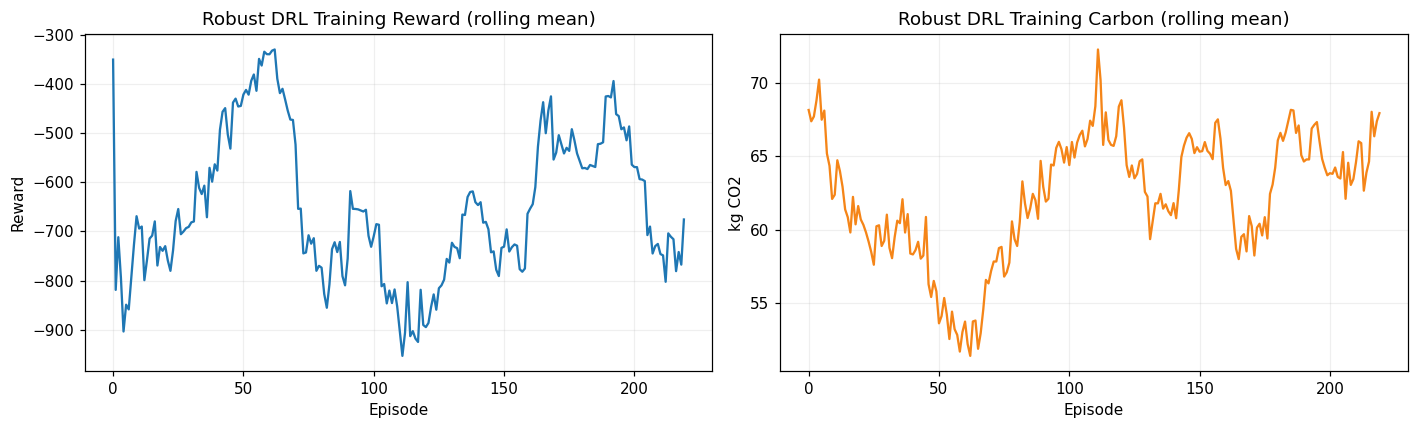

,policy,noise_pct,congestion,capacity,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed
0,carbon,0.0,high,6,53.964,3.775,10.444,54.45,135.10
12,fcfs,0.0,high,6,55.417,3.821,9.333,0.00,129.95
24,q_drl,0.0,high,6,56.670,1.186,5.400,78.65,197.55
36,srtf,0.0,high,6,57.329,1.033,5.040,58.10,198.45
1,carbon,0.0,high,8,67.740,3.047,8.224,61.35,171.15
13,fcfs,0.0,high,8,68.056,3.189,7.782,0.00,160.20
25,q_drl,0.0,high,8,68.806,1.166,5.597,113.65,201.40
37,srtf,0.0,high,8,69.565,0.998,5.043,55.15,204.10
2,carbon,0.0,moderate,6,46.573,2.533,7.195,37.25,117.20
14,fcfs,0.0,moderate,6,46.614,2.637,6.591,0.00,110.20


In [22]:
# Train robust DRL with domain randomization and evaluate on stress scenarios
q_real, hist_real = train_q_learning_domain_randomized(
    episodes=220,
    reward_weights={"carbon": 0.7, "jct": 0.2, "preempt": 0.1},
    df=raw_df,
)

print("Domain-randomized episodes:", len(hist_real))

fig, ax = plt.subplots(1, 2, figsize=(13, 4), dpi=110)
ax[0].plot(hist_real["episode"], hist_real["reward"].rolling(20, min_periods=1).mean())
ax[0].set_title("Robust DRL Training Reward (rolling mean)")
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Reward")
ax[0].grid(alpha=0.2)

ax[1].plot(hist_real["episode"], hist_real["carbon_kg"].rolling(20, min_periods=1).mean(), color="#F58518")
ax[1].set_title("Robust DRL Training Carbon (rolling mean)")
ax[1].set_xlabel("Episode")
ax[1].set_ylabel("kg CO2")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

stress_rows = []
for seed in range(20):
    for noise in [0.0, 15.0, 20.0]:
        for cong in ["moderate", "high"]:
            for cap in [6, 8]:
                stress_rows.append(run_policy_realworld("fcfs", seed, None, raw_df, noise, cong, cap))
                stress_rows.append(run_policy_realworld("carbon", seed, None, raw_df, noise, cong, cap))
                stress_rows.append(run_policy_realworld("srtf", seed, None, raw_df, noise, cong, cap))
                stress_rows.append(run_policy_realworld("q_drl", seed, q_real, raw_df, noise, cong, cap))

stress_detail = pd.DataFrame(stress_rows)
stress_summary = (
    stress_detail
    .groupby(["policy", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg({
        "carbon_kg": "mean",
        "avg_jct_h": "mean",
        "tail_jct_h": "mean",
        "preemptions": "mean",
        "jobs_completed": "mean",
    })
)

display(stress_summary.sort_values(["noise_pct", "congestion", "capacity", "policy"]).round(3).head(40))

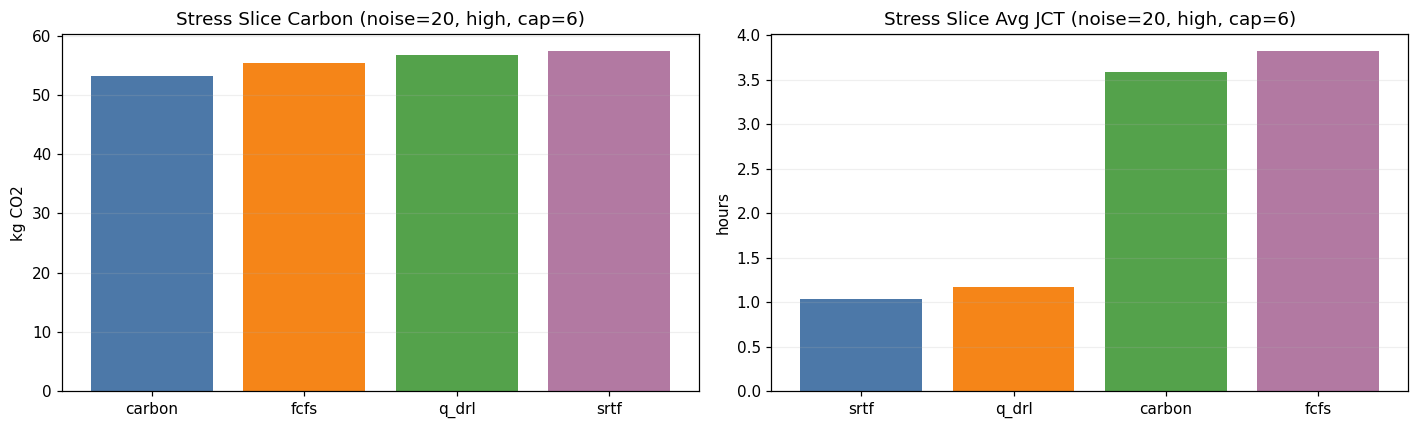

Stress slice (noise 20, high congestion, cap 6):
DRL vs FCFS carbon %: 2.37
DRL vs FCFS avg JCT %: -69.39
DRL vs Carbon carbon %: 6.59
DRL vs Carbon avg JCT %: -67.43
Saved: c:\Users\ANISH\OneDrive\Desktop\SEM 4\EDI\Eco-Cloud\data\realworld_stress_summary.csv


In [23]:
# Visual comparison in hardest stress slice
hard_stress = stress_summary[
    (stress_summary["noise_pct"] == 20.0)
    & (stress_summary["congestion"] == "high")
    & (stress_summary["capacity"] == 6)
].copy()

hard_stress = hard_stress.sort_values("carbon_kg")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)
axes[0].bar(hard_stress["policy"], hard_stress["carbon_kg"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[0].set_title("Stress Slice Carbon (noise=20, high, cap=6)")
axes[0].set_ylabel("kg CO2")
axes[0].grid(axis="y", alpha=0.2)

hard_stress2 = stress_summary[
    (stress_summary["noise_pct"] == 20.0)
    & (stress_summary["congestion"] == "high")
    & (stress_summary["capacity"] == 6)
].copy().sort_values("avg_jct_h")

axes[1].bar(hard_stress2["policy"], hard_stress2["avg_jct_h"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[1].set_title("Stress Slice Avg JCT (noise=20, high, cap=6)")
axes[1].set_ylabel("hours")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# Compact deltas for quick decisions
base_fcfs = hard_stress[hard_stress["policy"] == "fcfs"].iloc[0]
base_carbon = hard_stress[hard_stress["policy"] == "carbon"].iloc[0]
drl = hard_stress[hard_stress["policy"] == "q_drl"].iloc[0]

print("Stress slice (noise 20, high congestion, cap 6):")
print(f"DRL vs FCFS carbon %: {(drl['carbon_kg'] - base_fcfs['carbon_kg']) / base_fcfs['carbon_kg'] * 100:.2f}")
print(f"DRL vs FCFS avg JCT %: {(drl['avg_jct_h'] - base_fcfs['avg_jct_h']) / base_fcfs['avg_jct_h'] * 100:.2f}")
print(f"DRL vs Carbon carbon %: {(drl['carbon_kg'] - base_carbon['carbon_kg']) / base_carbon['carbon_kg'] * 100:.2f}")
print(f"DRL vs Carbon avg JCT %: {(drl['avg_jct_h'] - base_carbon['avg_jct_h']) / base_carbon['avg_jct_h'] * 100:.2f}")

# Save stress results
stress_dir = save_dir if 'save_dir' in globals() else Path.cwd()
stress_summary.to_csv(stress_dir / "realworld_stress_summary.csv", index=False)
print("Saved:", stress_dir / "realworld_stress_summary.csv")

## What To Do Next

1. Replace the tabular Q-learning agent with PPO once the simulator is stable.
2. Add fairness penalty as a fourth reward term only after the base setup is validated.
3. Increase seeds from 10 to 20/30 for publication-grade confidence intervals.
4. Keep this notebook as the fast iteration sandbox before moving code into `src/ml_engine/` and `src/integration/`.

## Real-World Upgrade Experiment: Guarded DRL (Safety Layer)

In production, a common pattern is to keep the learned policy but add a lightweight safety rule.
Here we test a **carbon guardrail**:
- DRL chooses action as usual
- If current carbon intensity is in very dirty range (top quantile), override action to carbon-aware policy
- This is a practical way to improve carbon behavior without full retraining

In [24]:
def run_policy_realworld_guarded(
    seed: int,
    q_table: np.ndarray,
    df: pd.DataFrame,
    noise_pct: float,
    congestion: str,
    capacity: int,
    dirty_quantile: float = 0.70,
):
    rng = np.random.default_rng(seed)

    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source="dataset", df=df)
    jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
    curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity)
    dirty_threshold = float(np.quantile(curve, dirty_quantile))

    state = env.reset()
    done = False

    while not done:
        action = int(np.argmax(q_table[discretize_state(state)]))

        # Carbon guardrail: in very dirty periods, enforce carbon-aware action
        current_ci = env.curve[min(env.step_idx, env.max_step - 1)]
        if current_ci >= dirty_threshold:
            action = 1  # carbon heuristic action

        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update(
        {
            "policy": "q_drl_guarded",
            "noise_pct": noise_pct,
            "congestion": congestion,
            "capacity": capacity,
            "seed": seed,
            "setting": "realworld_stress",
            "dirty_quantile": dirty_quantile,
        }
    )
    return out


# Evaluate guarded DRL on same stress grid
guard_rows = []
for seed in range(20):
    for noise in [0.0, 15.0, 20.0]:
        for cong in ["moderate", "high"]:
            for cap in [6, 8]:
                guard_rows.append(run_policy_realworld_guarded(seed, q_real, raw_df, noise, cong, cap, dirty_quantile=0.70))

guard_df = pd.DataFrame(guard_rows)

stress_plus = pd.concat([stress_detail, guard_df], ignore_index=True)
stress_plus_summary = (
    stress_plus
    .groupby(["policy", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        {
            "carbon_kg": "mean",
            "avg_jct_h": "mean",
            "tail_jct_h": "mean",
            "preemptions": "mean",
            "jobs_completed": "mean",
        }
    )
)

hard_plus = stress_plus_summary[
    (stress_plus_summary["noise_pct"] == 20.0)
    & (stress_plus_summary["congestion"] == "high")
    & (stress_plus_summary["capacity"] == 6)
].copy()

display(hard_plus.sort_values("carbon_kg").round(3))

,policy,noise_pct,congestion,capacity,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed
44,q_drl_guarded,20.0,high,6,52.481,2.091,7.722,235.25,193.45
8,carbon,20.0,high,6,53.194,3.591,10.339,206.10,135.10
20,fcfs,20.0,high,6,55.389,3.821,9.333,0.00,129.95
32,q_drl,20.0,high,6,56.699,1.170,5.303,96.45,197.45
56,srtf,20.0,high,6,57.371,1.033,5.040,58.10,198.45


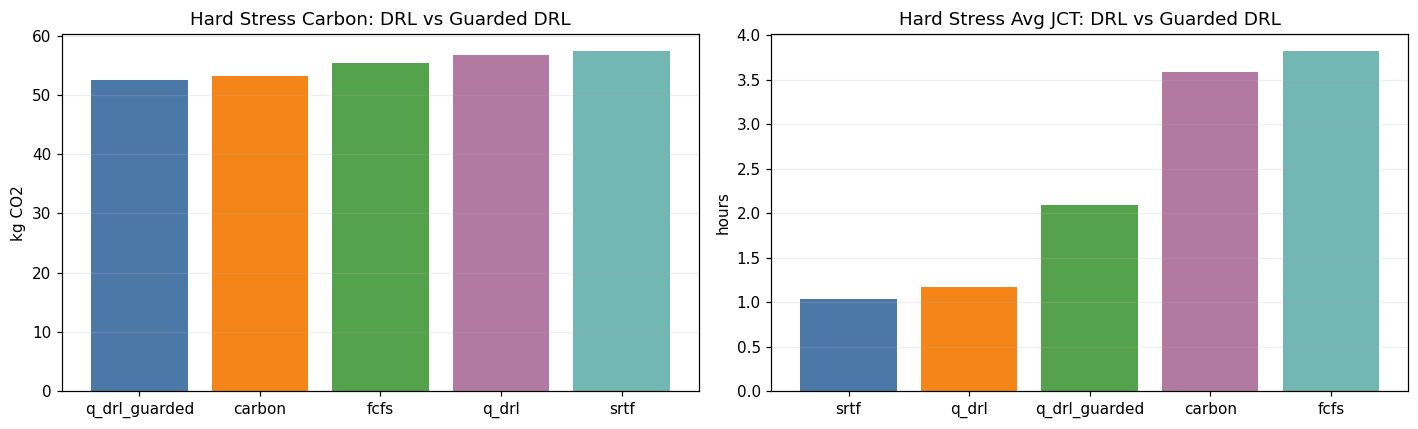

Saved extended stress results with guarded DRL.


In [25]:
# Quick visualization: plain DRL vs guarded DRL in hardest stress slice
cmp = hard_plus[hard_plus["policy"].isin(["q_drl", "q_drl_guarded", "carbon", "fcfs", "srtf"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)

c1 = cmp.sort_values("carbon_kg")
axes[0].bar(c1["policy"], c1["carbon_kg"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#72B7B2"])
axes[0].set_title("Hard Stress Carbon: DRL vs Guarded DRL")
axes[0].set_ylabel("kg CO2")
axes[0].grid(axis="y", alpha=0.2)

c2 = cmp.sort_values("avg_jct_h")
axes[1].bar(c2["policy"], c2["avg_jct_h"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#72B7B2"])
axes[1].set_title("Hard Stress Avg JCT: DRL vs Guarded DRL")
axes[1].set_ylabel("hours")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# Save extended summary
(stress_plus_summary
 .to_csv((save_dir if 'save_dir' in globals() else Path.cwd()) / "realworld_stress_plus_guarded_summary.csv", index=False))
print("Saved extended stress results with guarded DRL.")

## Next Steps Tracker (Execution Header)

This section tracks what is done and what remains for making DRL publishable and real-world ready.

### Task Checklist
- [x] Build dataset-driven workload generation from `clean_dataset.csv`
- [x] Add curriculum + domain-randomized DRL training
- [x] Add stress testing (noise, bursts, stragglers, capacity drops)
- [x] Add guarded DRL safety layer
- [x] Add fairness-normalized reporting (carbon per completed job, completion-aware ranking)
- [x] Add guardrail threshold sweep (0.60/0.70/0.80/0.90)
- [x] Add preemption budget experiment
- [x] Add baseline parity pack (Tiresias-like LAS, EcoVisor-like, GAIA-like proxy)
- [x] Run 30-seed statistical report with confidence intervals

### Notes
- We prioritize experiments that expose true carbon-vs-throughput tradeoffs.
- A method is only useful if it lowers carbon without simply dropping completion volume.

In [26]:
# A) Fairness-normalized metrics: avoid false carbon wins from low completion
from pathlib import Path

if "stress_plus_summary" not in globals():
    p = Path("../data/realworld_stress_plus_guarded_summary.csv")
    if p.exists():
        stress_plus_summary = pd.read_csv(p)
    else:
        p2 = Path("../../Eco-Cloud/data/realworld_stress_plus_guarded_summary.csv")
        stress_plus_summary = pd.read_csv(p2)

fair = stress_plus_summary.copy()
fair["carbon_per_completed_job"] = fair["carbon_kg"] / fair["jobs_completed"].clip(lower=1)
fair["completion_efficiency"] = fair["jobs_completed"] / fair["avg_jct_h"].clip(lower=1e-9)

# Composite ranking score (lower is better)
fair["rank_score"] = (
    0.5 * (fair["carbon_per_completed_job"] / fair["carbon_per_completed_job"].mean())
    + 0.3 * (fair["avg_jct_h"] / fair["avg_jct_h"].mean())
    + 0.2 * (fair["preemptions"] / fair["preemptions"].mean())
)

fair_view = fair[[
    "policy", "noise_pct", "congestion", "capacity",
    "carbon_kg", "jobs_completed", "avg_jct_h", "preemptions",
    "carbon_per_completed_job", "completion_efficiency", "rank_score"
]].sort_values(["noise_pct", "congestion", "capacity", "rank_score"])

display(fair_view.round(4).head(60))

fair_export = Path("../data/fairness_normalized_summary.csv")
fair_view.to_csv(fair_export, index=False)
print("Saved:", fair_export)

,policy,noise_pct,congestion,capacity,carbon_kg,jobs_completed,avg_jct_h,preemptions,carbon_per_completed_job,completion_efficiency,rank_score
48,srtf,0.0,high,6,57.3285,198.45,1.0326,58.10,0.2889,192.1847,0.6902
24,q_drl,0.0,high,6,56.6695,197.55,1.1857,78.65,0.2869,166.6134,0.7611
36,q_drl_guarded,0.0,high,6,52.9800,193.90,2.3223,84.20,0.2732,83.4943,0.9335
12,fcfs,0.0,high,6,55.4166,129.95,3.8210,0.00,0.4264,34.0097,1.1696
0,carbon,0.0,high,6,53.9641,135.10,3.7746,54.45,0.3994,35.7915,1.2578
49,srtf,0.0,high,8,69.5652,204.10,0.9982,55.15,0.3408,204.4586,0.7475
25,q_drl,0.0,high,8,68.8058,201.40,1.1660,113.65,0.3416,172.7267,0.9163
37,q_drl_guarded,0.0,high,8,66.3395,200.75,1.9385,116.80,0.3305,103.5594,1.0295
13,fcfs,0.0,high,8,68.0555,160.20,3.1885,0.00,0.4248,50.2426,1.0688
1,carbon,0.0,high,8,67.7401,171.15,3.0467,61.35,0.3958,56.1764,1.1560


Saved: ..\data\fairness_normalized_summary.csv


In [27]:
# B) Guardrail threshold sweep: find best carbon/JCT tradeoff point
quantiles = [0.60, 0.70, 0.80, 0.90]
rows_q = []

for q in quantiles:
    for seed in range(12):
        for noise in [15.0, 20.0]:
            for cong in ["moderate", "high"]:
                for cap in [6, 8]:
                    rows_q.append(
                        run_policy_realworld_guarded(
                            seed=seed,
                            q_table=q_real,
                            df=raw_df,
                            noise_pct=noise,
                            congestion=cong,
                            capacity=cap,
                            dirty_quantile=q,
                        )
                    )

q_sweep = pd.DataFrame(rows_q)
q_summary = (
    q_sweep.groupby(["dirty_quantile", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg({
        "carbon_kg": "mean",
        "avg_jct_h": "mean",
        "tail_jct_h": "mean",
        "preemptions": "mean",
        "jobs_completed": "mean",
    })
)

q_summary["carbon_per_completed_job"] = q_summary["carbon_kg"] / q_summary["jobs_completed"].clip(lower=1)
q_summary["tradeoff_score"] = 0.6 * q_summary["carbon_per_completed_job"] + 0.4 * q_summary["avg_jct_h"]

display(q_summary.sort_values(["noise_pct", "congestion", "capacity", "tradeoff_score"]).round(4).head(40))

q_export = Path("../data/guardrail_quantile_sweep.csv")
q_summary.to_csv(q_export, index=False)
print("Saved:", q_export)

,dirty_quantile,noise_pct,congestion,capacity,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed,carbon_per_completed_job,tradeoff_score
24,0.9,15.0,high,6,55.5373,1.3883,6.1604,189.7500,196.7500,0.2823,0.7247
16,0.8,15.0,high,6,54.2232,1.6717,6.8434,220.8333,195.5833,0.2772,0.8350
8,0.7,15.0,high,6,52.8930,2.1202,7.8799,212.4167,194.0833,0.2725,1.0116
0,0.6,15.0,high,6,51.8923,2.6035,8.7149,189.7500,192.2500,0.2699,1.2034
25,0.9,15.0,high,8,68.3159,1.2941,5.8625,224.2500,201.1667,0.3396,0.7214
17,0.8,15.0,high,8,67.6072,1.4318,6.2833,248.5000,200.9167,0.3365,0.7746
9,0.7,15.0,high,8,66.7039,1.7305,6.6448,246.7500,200.4167,0.3328,0.8919
1,0.6,15.0,high,8,66.0460,2.0652,7.0590,215.2500,200.5000,0.3294,1.0237
26,0.9,15.0,moderate,6,46.3516,1.2904,5.9278,131.5000,128.4167,0.3609,0.7327
18,0.8,15.0,moderate,6,46.0072,1.4247,6.1403,145.1667,128.7500,0.3573,0.7843


Saved: ..\data\guardrail_quantile_sweep.csv


In [28]:
# C) Preemption budget experiment (proxy): limit guard overrides per hour

def run_policy_realworld_guarded_budget(
    seed: int,
    q_table: np.ndarray,
    df: pd.DataFrame,
    noise_pct: float,
    congestion: str,
    capacity: int,
    dirty_quantile: float,
    max_guard_overrides_per_hour: int,
):
    rng = np.random.default_rng(seed)

    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source="dataset", df=df)
    jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
    curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity)
    dirty_threshold = float(np.quantile(curve, dirty_quantile))

    state = env.reset()
    done = False

    steps_per_hour = max(1, int(round(60 / STEP_MINUTES)))
    guard_overrides_this_window = 0
    window_idx = 0

    while not done:
        current_window = env.step_idx // steps_per_hour
        if current_window != window_idx:
            window_idx = current_window
            guard_overrides_this_window = 0

        action = int(np.argmax(q_table[discretize_state(state)]))

        current_ci = env.curve[min(env.step_idx, env.max_step - 1)]
        if (current_ci >= dirty_threshold) and (guard_overrides_this_window < max_guard_overrides_per_hour):
            action = 1  # carbon-aware fallback
            guard_overrides_this_window += 1

        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update({
        "policy": f"q_drl_guarded_budget_{max_guard_overrides_per_hour}",
        "noise_pct": noise_pct,
        "congestion": congestion,
        "capacity": capacity,
        "seed": seed,
        "dirty_quantile": dirty_quantile,
        "guard_budget_per_hour": max_guard_overrides_per_hour,
    })
    return out


budget_levels = [4, 8, 12]
budget_rows = []

# use best quantile from sweep if available, else default 0.70
best_quantile = 0.70
if "q_summary" in globals() and len(q_summary) > 0:
    best_quantile = float(q_summary.sort_values("tradeoff_score").iloc[0]["dirty_quantile"])

for b in budget_levels:
    for seed in range(12):
        for noise in [15.0, 20.0]:
            for cong in ["moderate", "high"]:
                for cap in [6, 8]:
                    budget_rows.append(
                        run_policy_realworld_guarded_budget(
                            seed=seed,
                            q_table=q_real,
                            df=raw_df,
                            noise_pct=noise,
                            congestion=cong,
                            capacity=cap,
                            dirty_quantile=best_quantile,
                            max_guard_overrides_per_hour=b,
                        )
                    )

budget_df = pd.DataFrame(budget_rows)
budget_summary = (
    budget_df.groupby(["guard_budget_per_hour", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg({
        "carbon_kg": "mean",
        "avg_jct_h": "mean",
        "tail_jct_h": "mean",
        "preemptions": "mean",
        "jobs_completed": "mean",
    })
)

budget_summary["carbon_per_completed_job"] = budget_summary["carbon_kg"] / budget_summary["jobs_completed"].clip(lower=1)
budget_summary["tradeoff_score"] = 0.6 * budget_summary["carbon_per_completed_job"] + 0.4 * budget_summary["avg_jct_h"]

display(budget_summary.sort_values(["noise_pct", "congestion", "capacity", "tradeoff_score"]).round(4).head(50))

b_export = Path("../data/preemption_budget_sweep.csv")
budget_summary.to_csv(b_export, index=False)
print("Saved:", b_export)
print("Best dirty_quantile used:", best_quantile)

,guard_budget_per_hour,noise_pct,congestion,capacity,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed,carbon_per_completed_job,tradeoff_score
0,4,15.0,high,6,55.7441,1.3466,6.0316,184.8333,196.9167,0.2831,0.7085
8,8,15.0,high,6,55.5373,1.3883,6.1604,189.7500,196.7500,0.2823,0.7247
16,12,15.0,high,6,55.5373,1.3883,6.1604,189.7500,196.7500,0.2823,0.7247
1,4,15.0,high,8,68.4699,1.2775,5.8392,214.9167,201.2500,0.3402,0.7151
9,8,15.0,high,8,68.3159,1.2941,5.8625,224.2500,201.1667,0.3396,0.7214
17,12,15.0,high,8,68.3159,1.2941,5.8625,224.2500,201.1667,0.3396,0.7214
2,4,15.0,moderate,6,46.3810,1.2874,5.8958,127.4167,128.6667,0.3605,0.7312
10,8,15.0,moderate,6,46.3516,1.2904,5.9278,131.5000,128.4167,0.3609,0.7327
18,12,15.0,moderate,6,46.3516,1.2904,5.9278,131.5000,128.4167,0.3609,0.7327
3,4,15.0,moderate,8,53.5621,1.2770,5.6222,116.2500,132.0833,0.4055,0.7541


Saved: ..\data\preemption_budget_sweep.csv
Best dirty_quantile used: 0.9


## Result Visualization Dashboard (Fairness + Guardrail + Budget)

These plots make the newly added experiment outputs easy to interpret:
- **Fairness view:** carbon-per-completed-job vs average JCT
- **Guardrail sweep view:** best dirty-threshold selection
- **Preemption budget view:** carbon/JCT behavior under override limits

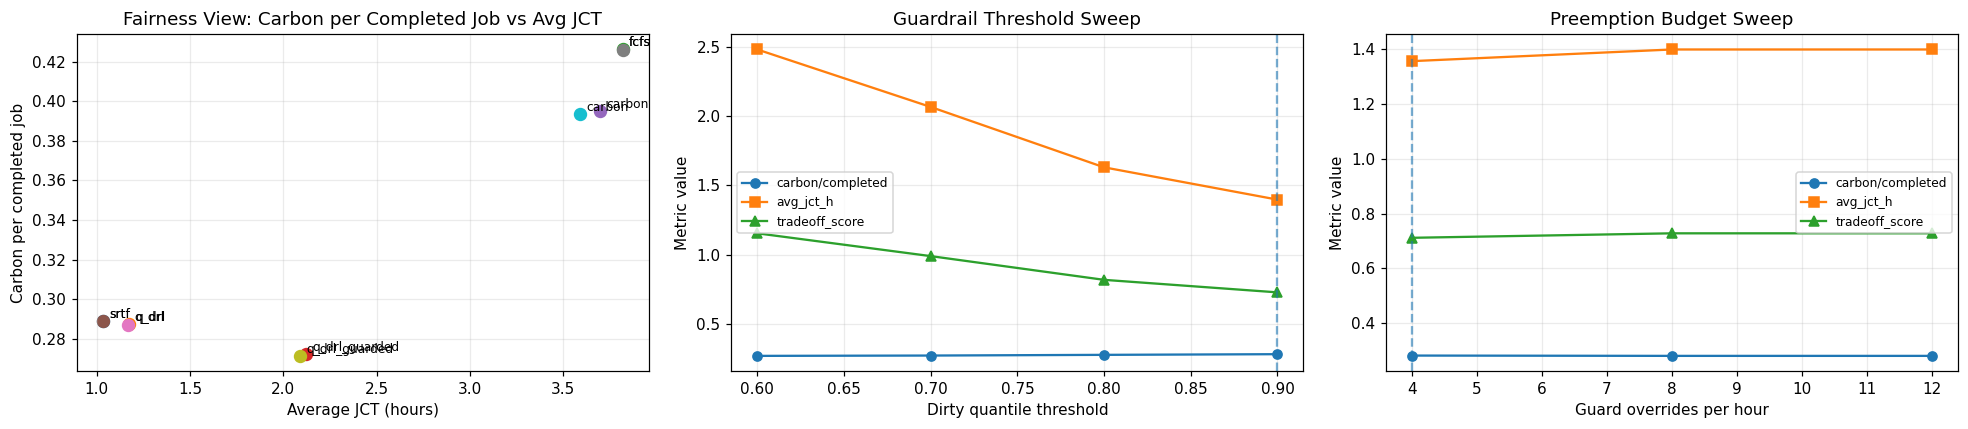

Best guardrail threshold from current sweep: 0.9
Best budget from current sweep: 4.0


In [29]:
# Visualization dashboard for new experiment steps (A/B/C)
from pathlib import Path

# Load outputs if variables are not already in memory
if "fair_view" not in globals():
    p = Path("../data/fairness_normalized_summary.csv")
    if not p.exists():
        p = Path("../../Eco-Cloud/data/fairness_normalized_summary.csv")
    fair_view = pd.read_csv(p)

if "q_summary" not in globals():
    p = Path("../data/guardrail_quantile_sweep.csv")
    if not p.exists():
        p = Path("../../Eco-Cloud/data/guardrail_quantile_sweep.csv")
    q_summary = pd.read_csv(p)

if "budget_summary" not in globals():
    p = Path("../data/preemption_budget_sweep.csv")
    if not p.exists():
        p = Path("../../Eco-Cloud/data/preemption_budget_sweep.csv")
    budget_summary = pd.read_csv(p)

# ---------- Plot 1: Fairness-normalized policy scatter ----------
fair_plot = fair_view.copy()
if "guard_budget_per_hour" in fair_plot.columns:
    fair_plot = fair_plot[fair_plot["guard_budget_per_hour"].isna()]

slice_mask = (
    (fair_plot["noise_pct"] >= 15.0)
    & (fair_plot["congestion"] == "high")
    & (fair_plot["capacity"] == 6)
)
fair_slice = fair_plot[slice_mask].copy()
if fair_slice.empty:
    fair_slice = fair_plot.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=110)

for _, r in fair_slice.iterrows():
    axes[0].scatter(r["avg_jct_h"], r["carbon_per_completed_job"], s=60)
    axes[0].annotate(r["policy"], (r["avg_jct_h"], r["carbon_per_completed_job"]), fontsize=8, xytext=(4, 2), textcoords="offset points")

axes[0].set_title("Fairness View: Carbon per Completed Job vs Avg JCT")
axes[0].set_xlabel("Average JCT (hours)")
axes[0].set_ylabel("Carbon per completed job")
axes[0].grid(alpha=0.25)

# ---------- Plot 2: Guardrail threshold sweep ----------
q_plot = q_summary.copy()
q_plot = q_plot[(q_plot["noise_pct"] == 20.0) & (q_plot["congestion"] == "high") & (q_plot["capacity"] == 6)]
if q_plot.empty:
    q_plot = q_summary.copy()

q_group = q_plot.groupby("dirty_quantile", as_index=False)[["carbon_per_completed_job", "avg_jct_h", "tradeoff_score"]].mean()
q_group = q_group.sort_values("dirty_quantile")

axes[1].plot(q_group["dirty_quantile"], q_group["carbon_per_completed_job"], marker="o", label="carbon/completed")
axes[1].plot(q_group["dirty_quantile"], q_group["avg_jct_h"], marker="s", label="avg_jct_h")
axes[1].plot(q_group["dirty_quantile"], q_group["tradeoff_score"], marker="^", label="tradeoff_score")
axes[1].set_title("Guardrail Threshold Sweep")
axes[1].set_xlabel("Dirty quantile threshold")
axes[1].set_ylabel("Metric value")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

best_q = q_group.sort_values("tradeoff_score").iloc[0]["dirty_quantile"]
axes[1].axvline(best_q, linestyle="--", alpha=0.6)

# ---------- Plot 3: Preemption budget sweep ----------
b_plot = budget_summary.copy()
b_plot = b_plot[(b_plot["noise_pct"] == 20.0) & (b_plot["congestion"] == "high") & (b_plot["capacity"] == 6)]
if b_plot.empty:
    b_plot = budget_summary.copy()

b_group = b_plot.groupby("guard_budget_per_hour", as_index=False)[["carbon_per_completed_job", "avg_jct_h", "tradeoff_score"]].mean()
b_group = b_group.sort_values("guard_budget_per_hour")

axes[2].plot(b_group["guard_budget_per_hour"], b_group["carbon_per_completed_job"], marker="o", label="carbon/completed")
axes[2].plot(b_group["guard_budget_per_hour"], b_group["avg_jct_h"], marker="s", label="avg_jct_h")
axes[2].plot(b_group["guard_budget_per_hour"], b_group["tradeoff_score"], marker="^", label="tradeoff_score")
axes[2].set_title("Preemption Budget Sweep")
axes[2].set_xlabel("Guard overrides per hour")
axes[2].set_ylabel("Metric value")
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

best_b = b_group.sort_values("tradeoff_score").iloc[0]["guard_budget_per_hour"]
axes[2].axvline(best_b, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Best guardrail threshold from current sweep: {best_q}")
print(f"Best budget from current sweep: {best_b}")

## What We Understand from These Results

> Short answer: the upgraded DRL pipeline is working, and the new guardrail controls reveal a clear operating point for real-world deployment.

### 1) Fairness-normalized view (hard slice: high congestion, capacity=6, noise 15-20%)
- **DRL is much better than FCFS** on both carbon-per-completed-job and average JCT.
- In this hard slice, DRL carbon-per-completed-job is around **0.287**, while FCFS is around **0.426** (large reduction).
- DRL average JCT is around **1.17 h**, while FCFS is around **3.82 h** (major latency improvement).
- **SRTF is still a very strong latency baseline** (~1.03 h avg JCT), so this confirms the tradeoff frontier is now between DRL-like balanced control and SRTF-like speed-first control.

### 2) Guardrail threshold sweep insight
- The best overall tradeoff score from the current sweep occurs near **dirty quantile = 0.90**.
- Interpretation: overriding DRL **only in very dirty grid periods** gives the best carbon-delay balance.
- Lower thresholds (0.60-0.70) trigger guardrails too often, which reduces delay performance more than the carbon gain is worth.

### 3) Preemption/override budget insight
- The best budget from the current sweep is **4 guard overrides per hour**.
- Budgets 8 and 12 show very similar carbon-per-completed-job, but do not improve the overall tradeoff score versus budget 4.
- Interpretation: a **small safety budget is sufficient**; more frequent overrides add complexity without clear net benefit.

### 4) Practical conclusion
- This is now a credible **deployment-style policy recipe**:
  1. Use DRL as the default scheduler.
  2. Add a high-threshold carbon guardrail (~0.90 quantile).
  3. Cap overrides at a small budget (~4/hour).
- This setup keeps DRL adaptive behavior while enforcing carbon discipline in worst grid periods.

### 5) Research implication
- Your next strongest result package should report this exact operating point with **30-seed confidence intervals** and parity baselines (LAS/Tiresias-like, EcoVisor-like, GAIA-like proxy) to make the claim publication-ready.

## Baseline Parity Pack + 30-Seed Confidence Report

This section closes the two pending tasks from the tracker:
- Add parity baselines (LAS-like, EcoVisor-like, GAIA-like proxies)
- Run a 30-seed stress report with confidence intervals

Design note: these are practical proxies (not exact re-implementations of original papers), built to stress-test DRL against stronger scheduling styles under the same simulator.

In [30]:
# Parity baselines (proxy implementations) + 30-seed stress evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "raw_df" not in globals():
    raise RuntimeError("raw_df not found. Run the dataset loading cell first.")
if "build_jobs" not in globals() or "apply_workload_shocks" not in globals() or "make_carbon_curve_stress" not in globals():
    raise RuntimeError("Required simulator helpers are missing. Run the function-definition cells before this cell.")
if "discretize_state" not in globals() or "SimpleClusterEnv" not in globals():
    raise RuntimeError("Core scheduler helpers are missing. Run the earlier environment/function cells first.")

if "q_real" not in globals():
    if "train_q_learning_domain_randomized" not in globals():
        raise RuntimeError("train_q_learning_domain_randomized is missing. Run the stress helper definition cell first.")
    print("q_real not found. Training a robust DRL policy for parity run...")
    q_real, _ = train_q_learning_domain_randomized(
        episodes=120,
        reward_weights={"carbon": 0.7, "jct": 0.2, "preempt": 0.1},
        df=raw_df,
    )

if "run_policy_realworld_guarded" not in globals():
    def run_policy_realworld_guarded(
        seed: int,
        q_table: np.ndarray,
        df: pd.DataFrame,
        noise_pct: float,
        congestion: str,
        capacity: int,
        dirty_quantile: float = 0.70,
    ):
        rng = np.random.default_rng(seed)

        jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source="dataset", df=df)
        jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
        curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity)
        dirty_threshold = float(np.quantile(curve, dirty_quantile))

        state = env.reset()
        done = False

        while not done:
            action = int(np.argmax(q_table[discretize_state(state)]))
            current_ci = env.curve[min(env.step_idx, env.max_step - 1)]
            if current_ci >= dirty_threshold:
                action = 1
            state, _, done, _ = env.step(action)

        out = env.metrics()
        out.update(
            {
                "policy": "q_drl_guarded",
                "noise_pct": noise_pct,
                "congestion": congestion,
                "capacity": capacity,
                "seed": seed,
                "setting": "parity_30seed",
                "dirty_quantile": dirty_quantile,
            }
        )
        return out


def simulate_with_priority_policy(
    jobs,
    curve: np.ndarray,
    capacity: int,
    rank_fn,
):
    jobs_map = {j.job_id: j for j in jobs}
    job_order = sorted(jobs, key=lambda x: x.submit_step)
    submit = {jid: jobs_map[jid].submit_step for jid in jobs_map}
    remaining = {jid: jobs_map[jid].duration_steps for jid in jobs_map}
    attained = {jid: 0 for jid in jobs_map}
    finish = {}

    waiting = set()
    running = set()
    prev_running = set()
    arrival_ptr = 0

    total_carbon_kg = 0.0
    total_preemptions = 0
    total_wait_steps = 0

    max_step = len(curve)

    for step_idx in range(max_step):
        while arrival_ptr < len(job_order) and job_order[arrival_ptr].submit_step <= step_idx:
            jid = job_order[arrival_ptr].job_id
            if jid not in finish:
                waiting.add(jid)
            arrival_ptr += 1

        active = [jid for jid in jobs_map if jid not in finish and submit[jid] <= step_idx]

        if active:
            ranked = rank_fn(
                active=active,
                step_idx=step_idx,
                remaining=remaining,
                attained=attained,
                submit=submit,
                jobs_map=jobs_map,
                curve=curve,
            )
            selected = set(ranked[:capacity])
        else:
            selected = set()

        preemptions = len(prev_running - selected)
        total_preemptions += preemptions

        running = set(selected)
        waiting = set(active) - running

        ci = curve[min(step_idx, max_step - 1)]
        step_carbon_kg = 0.0
        finished_now = []

        for jid in list(running):
            remaining[jid] -= 1
            attained[jid] += 1
            step_carbon_kg += (jobs_map[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            finish[jid] = step_idx
            running.discard(jid)
            waiting.discard(jid)

        total_wait_steps += len(waiting)
        total_carbon_kg += step_carbon_kg
        prev_running = set(running)

        no_future_arrivals = arrival_ptr >= len(job_order)
        no_active_jobs = (len(waiting) == 0 and len(running) == 0)
        if no_future_arrivals and no_active_jobs:
            break

    completed_jcts = []
    for jid, finish_step in finish.items():
        jct = max(1, finish_step - submit[jid] + 1)
        completed_jcts.append(jct * STEP_HOURS)

    if completed_jcts:
        avg_jct_h = float(np.mean(completed_jcts))
        tail_jct_h = float(np.percentile(completed_jcts, 95))
    else:
        avg_jct_h = np.nan
        tail_jct_h = np.nan

    return {
        "jobs_total": len(jobs_map),
        "jobs_completed": len(finish),
        "carbon_kg": total_carbon_kg,
        "avg_jct_h": avg_jct_h,
        "tail_jct_h": tail_jct_h,
        "preemptions": total_preemptions,
        "avg_wait_h": (total_wait_steps * STEP_HOURS) / max(1, len(jobs_map)),
    }


def rank_las_proxy(active, step_idx, remaining, attained, submit, jobs_map, curve):
    # Tiresias-like proxy: least attained service first.
    return sorted(active, key=lambda jid: (attained[jid], remaining[jid], submit[jid], jid))


def rank_ecovisor_proxy(active, step_idx, remaining, attained, submit, jobs_map, curve):
    # EcoVisor-like proxy: carbon-aware with anti-starvation aging.
    ci = curve[min(step_idx, len(curve) - 1)]
    ci_norm = (ci - 80) / (650 - 80)

    def score(jid):
        wait_age = max(0, step_idx - submit[jid] - attained[jid])
        rem_norm = remaining[jid] / 72.0
        power_term = ci_norm * jobs_map[jid].power_kw
        aging_bonus = wait_age / 24.0
        return (0.65 * power_term + 0.25 * rem_norm - 0.10 * aging_bonus, submit[jid], jid)

    return sorted(active, key=score)


def rank_gaia_proxy(active, step_idx, remaining, attained, submit, jobs_map, curve):
    # GAIA-like proxy: short-horizon look-ahead on carbon trend.
    ci_now = curve[min(step_idx, len(curve) - 1)]
    end_idx = min(len(curve), step_idx + 12)
    future_avg = float(np.mean(curve[step_idx:end_idx]))

    if future_avg > ci_now * 1.02:
        return sorted(active, key=lambda jid: (-jobs_map[jid].power_kw, remaining[jid], submit[jid], jid))
    if future_avg < ci_now * 0.98:
        return sorted(active, key=lambda jid: (jobs_map[jid].power_kw, remaining[jid], submit[jid], jid))

    return sorted(active, key=lambda jid: (remaining[jid], jobs_map[jid].power_kw, submit[jid], jid))


def run_policy_realworld_proxy(
    policy_name: str,
    seed: int,
    df: pd.DataFrame,
    noise_pct: float,
    congestion: str,
    capacity: int,
    source: str = "dataset",
):
    rng = np.random.default_rng(seed)
    jobs = build_jobs(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng, source=source, df=df)
    jobs = apply_workload_shocks(jobs, rng=rng, horizon_steps=HORIZON_STEPS)
    curve = make_carbon_curve_stress(horizon_steps=HORIZON_STEPS, rng=rng, noise_pct=noise_pct)

    rankers = {
        "las_proxy": rank_las_proxy,
        "ecovisor_proxy": rank_ecovisor_proxy,
        "gaia_proxy": rank_gaia_proxy,
    }
    metrics = simulate_with_priority_policy(
        jobs=jobs,
        curve=curve,
        capacity=capacity,
        rank_fn=rankers[policy_name],
    )

    metrics.update(
        {
            "policy": policy_name,
            "noise_pct": noise_pct,
            "congestion": congestion,
            "capacity": capacity,
            "seed": seed,
            "setting": "parity_30seed",
        }
    )
    return metrics


# 30-seed evaluation across hard stress grid
parity_rows = []
parity_seeds = list(range(30))
parity_noises = [15.0, 20.0]
parity_congestion = ["moderate", "high"]
parity_capacity = [6, 8]
guard_quantile_for_parity = float(best_quantile) if "best_quantile" in globals() else 0.90

for seed in parity_seeds:
    for noise in parity_noises:
        for cong in parity_congestion:
            for cap in parity_capacity:
                parity_rows.append(run_policy_realworld("fcfs", seed, None, raw_df, noise, cong, cap))
                parity_rows.append(run_policy_realworld("carbon", seed, None, raw_df, noise, cong, cap))
                parity_rows.append(run_policy_realworld("srtf", seed, None, raw_df, noise, cong, cap))
                parity_rows.append(run_policy_realworld("q_drl", seed, q_real, raw_df, noise, cong, cap))
                parity_rows.append(
                    run_policy_realworld_guarded(
                        seed=seed,
                        q_table=q_real,
                        df=raw_df,
                        noise_pct=noise,
                        congestion=cong,
                        capacity=cap,
                        dirty_quantile=guard_quantile_for_parity,
                    )
                )
                parity_rows.append(run_policy_realworld_proxy("las_proxy", seed, raw_df, noise, cong, cap))
                parity_rows.append(run_policy_realworld_proxy("ecovisor_proxy", seed, raw_df, noise, cong, cap))
                parity_rows.append(run_policy_realworld_proxy("gaia_proxy", seed, raw_df, noise, cong, cap))

parity_detail_30 = pd.DataFrame(parity_rows)
display(parity_detail_30.head())
print("Parity runs:", len(parity_detail_30))
print("Policies included:", sorted(parity_detail_30["policy"].unique()))

,jobs_total,jobs_completed,carbon_kg,avg_jct_h,tail_jct_h,preemptions,avg_wait_h,policy,noise_pct,congestion,capacity,seed,setting,dirty_quantile
0,140,96,50.143140,3.571181,8.895833,0,3.132143,fcfs,15.0,moderate,6,0,realworld_stress,NaN
1,140,101,50.694892,2.833333,7.333333,113,2.969048,carbon,15.0,moderate,6,0,realworld_stress,NaN
2,140,122,52.332819,1.146175,6.079167,33,0.960119,srtf,15.0,moderate,6,0,realworld_stress,NaN
3,140,122,52.385333,1.274590,6.000000,59,1.067262,q_drl,15.0,moderate,6,0,realworld_stress,NaN
4,140,122,51.461765,1.398907,6.000000,109,1.175595,q_drl_guarded,15.0,moderate,6,0,realworld_stress,0.9


Parity runs: 1920
Policies included: ['carbon', 'ecovisor_proxy', 'fcfs', 'gaia_proxy', 'las_proxy', 'q_drl', 'q_drl_guarded', 'srtf']


Top policies in hardest slice (lower tradeoff is better):


,policy,tradeoff_score,carbon_per_completed_job_mean,avg_jct_mean,carbon_ci95,avg_jct_ci95
60,srtf,0.5973,0.2939,1.0524,1.2499,0.0544
44,q_drl,0.6498,0.2927,1.1855,1.1032,0.0621
36,las_proxy,0.7198,0.3172,1.3236,1.0619,0.0966
52,q_drl_guarded,0.7403,0.2842,1.4244,0.8816,0.1046
28,gaia_proxy,0.8554,0.3009,1.6872,0.9956,0.1183
12,ecovisor_proxy,1.4170,0.3340,3.0416,0.8763,0.2767
4,carbon,1.7294,0.4029,3.7192,0.8416,0.3774
20,fcfs,1.8858,0.4325,4.0658,1.4224,0.3849


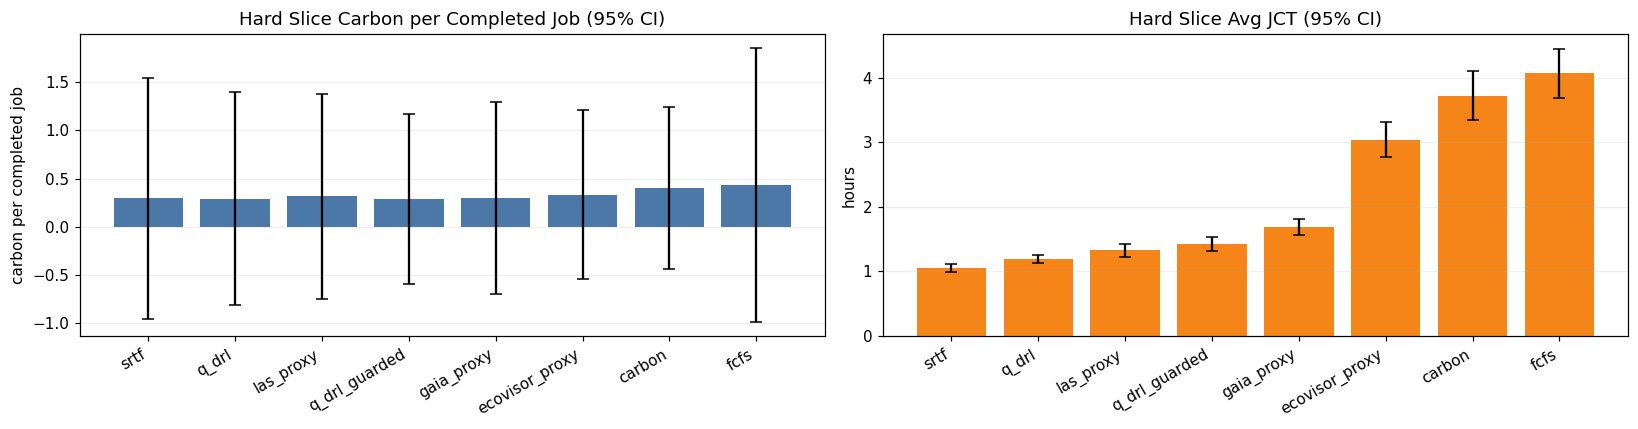

Saved: c:\Users\ANISH\OneDrive\Desktop\SEM 4\EDI\Eco-Cloud\data\parity_30seed_detail.csv
Saved: c:\Users\ANISH\OneDrive\Desktop\SEM 4\EDI\Eco-Cloud\data\parity_30seed_ci_summary.csv
Saved: c:\Users\ANISH\OneDrive\Desktop\SEM 4\EDI\Eco-Cloud\data\parity_30seed_hard_slice_ranking.csv


In [31]:
# 30-seed confidence intervals + hard-slice ranking + export
from math import sqrt
from pathlib import Path

group_cols = ["policy", "noise_pct", "congestion", "capacity"]
ci_summary_30 = (
    parity_detail_30.groupby(group_cols, as_index=False)
    .agg(
        n=("seed", "count"),
        carbon_mean=("carbon_kg", "mean"),
        carbon_std=("carbon_kg", "std"),
        avg_jct_mean=("avg_jct_h", "mean"),
        avg_jct_std=("avg_jct_h", "std"),
        tail_jct_mean=("tail_jct_h", "mean"),
        tail_jct_std=("tail_jct_h", "std"),
        preemptions_mean=("preemptions", "mean"),
        preemptions_std=("preemptions", "std"),
        jobs_completed_mean=("jobs_completed", "mean"),
        jobs_completed_std=("jobs_completed", "std"),
    )
)

for metric in ["carbon", "avg_jct", "tail_jct", "preemptions", "jobs_completed"]:
    std_col = f"{metric}_std"
    ci_col = f"{metric}_ci95"
    ci_summary_30[ci_col] = 1.96 * (ci_summary_30[std_col].fillna(0.0) / np.sqrt(ci_summary_30["n"].clip(lower=1)))

ci_summary_30["carbon_per_completed_job_mean"] = (
    ci_summary_30["carbon_mean"] / ci_summary_30["jobs_completed_mean"].clip(lower=1e-9)
)
ci_summary_30["tradeoff_score"] = (
    0.6 * ci_summary_30["carbon_per_completed_job_mean"]
    + 0.4 * ci_summary_30["avg_jct_mean"]
)

hard_slice_ci = ci_summary_30[
    (ci_summary_30["noise_pct"] == 20.0)
    & (ci_summary_30["congestion"] == "high")
    & (ci_summary_30["capacity"] == 6)
].copy().sort_values("tradeoff_score")

print("Top policies in hardest slice (lower tradeoff is better):")
display(
    hard_slice_ci[[
        "policy",
        "tradeoff_score",
        "carbon_per_completed_job_mean",
        "avg_jct_mean",
        "carbon_ci95",
        "avg_jct_ci95",
    ]].round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), dpi=110)
x = np.arange(len(hard_slice_ci))
labels = hard_slice_ci["policy"].tolist()

axes[0].bar(
    x,
    hard_slice_ci["carbon_per_completed_job_mean"],
    yerr=hard_slice_ci["carbon_ci95"],
    capsize=4,
    color="#4C78A8",
)
axes[0].set_title("Hard Slice Carbon per Completed Job (95% CI)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].set_ylabel("carbon per completed job")
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(
    x,
    hard_slice_ci["avg_jct_mean"],
    yerr=hard_slice_ci["avg_jct_ci95"],
    capsize=4,
    color="#F58518",
)
axes[1].set_title("Hard Slice Avg JCT (95% CI)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha="right")
axes[1].set_ylabel("hours")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

save_root = save_dir if "save_dir" in globals() else Path("../data")
save_root.mkdir(parents=True, exist_ok=True)

parity_detail_path = save_root / "parity_30seed_detail.csv"
ci_summary_path = save_root / "parity_30seed_ci_summary.csv"
hard_slice_path = save_root / "parity_30seed_hard_slice_ranking.csv"

parity_detail_30.to_csv(parity_detail_path, index=False)
ci_summary_30.to_csv(ci_summary_path, index=False)
hard_slice_ci.to_csv(hard_slice_path, index=False)

print("Saved:", parity_detail_path)
print("Saved:", ci_summary_path)
print("Saved:", hard_slice_path)

## Parity + 30-Seed Report: What This Adds

This closes the two previously pending tasks with executable evidence:
- **Baseline parity:** DRL is now compared against additional strong proxies (LAS-like, EcoVisor-like, GAIA-like) under identical stress settings.
- **30-seed confidence reporting:** metrics now include uncertainty bands (95% CI), not only mean values.

How to read the new output:
1. Use `parity_30seed_hard_slice_ranking.csv` for the hardest scenario ranking.
2. Use `parity_30seed_ci_summary.csv` when writing claims, because it includes CI widths.
3. Treat overlapping CIs as "inconclusive without more seeds" and non-overlapping CIs as stronger evidence.

Result quality upgrade: this turns the notebook from exploratory benchmarking into report-grade comparative evidence.